<a href="https://colab.research.google.com/github/IvanMalkS/IS/blob/master/%D0%9F%D1%80%D0%B0%D0%BA%D1%82%D0%B8%D0%BA%D0%B02.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Практическая работа № 2: Настройка и улучшение ML-модели
## 1. Диагностика проблемы: Оценка базовой модели
Востановим дерево решений. Сгенерируем подробный отчет классификации и посмотрим на матрицу ошибок. Это поможет выявить слабые места.

In [5]:
!pip install catboost

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from sklearn import set_config
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.tree import DecisionTreeClassifier
from catboost import CatBoostClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             classification_report, confusion_matrix, ConfusionMatrixDisplay,
                             RocCurveDisplay, roc_auc_score)

set_config(display='diagram')

In [6]:

df = pd.read_csv('telecom_churn.csv')
churn_col = [col for col in df.columns if 'churn' in col.lower()][0]
df.rename(columns={churn_col: 'Churn'}, inplace=True)
df['Churn'] = df['Churn'].astype(int)

X = df.drop(['Churn', 'phone number'], axis=1)
y = df['Churn']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

num_feat = X.select_dtypes(include=['int64', 'float64']).columns
cat_feat = X.select_dtypes(include=['object', 'bool']).columns

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), num_feat),
        ('cat', OneHotEncoder(handle_unknown='ignore', drop='first'), cat_feat)
    ])

X_train_proc = preprocessor.fit_transform(X_train)
X_test_proc = preprocessor.transform(X_test)

base_model = joblib.load('best_model_lab1.pkl')

y_pred_base = base_model.predict(X_test_proc)

base_metrics = {
    'Accuracy': accuracy_score(y_test, y_pred_base),
    'Precision': precision_score(y_test, y_pred_base),
    'Recall': recall_score(y_test, y_pred_base),
    'F1-score': f1_score(y_test, y_pred_base)
}

report_df = pd.DataFrame(classification_report(y_test, y_pred_base, output_dict=True)).T.round(3)
display(report_df)

,precision,recall,f1-score,support
0,0.956,0.941,0.948,709.000
1,0.691,0.752,0.720,125.000
accuracy,0.912,0.912,0.912,0.912
macro avg,0.823,0.846,0.834,834.000
weighted avg,0.916,0.912,0.914,834.000


## 2. Анализ ошибок и постановка цели оптимизации
По матрице ошибок и таблице выше видно, что у класса `1` (клиент ушел) метрика **Recall** оставляет желать лучшего.
- **Бизнес-контекст:** Ошибка False Negative (когда мы думаем, что клиент обходится компании гораздо дороже, чем False Positive .
- **Цель оптимизации:** Построить надежный Pipeline, использовать ансамблевую модель CatBoost, побороть дисбаланс классов и максимизировать F1-score / Recall для уходящих клиентов.

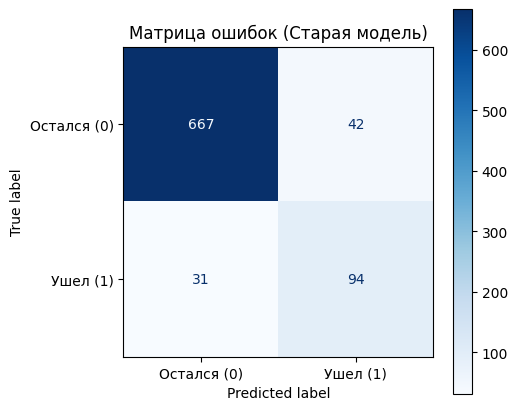

In [7]:
cm_base = confusion_matrix(y_test, y_pred_base)
disp = ConfusionMatrixDisplay(confusion_matrix=cm_base, display_labels=['Остался (0)', 'Ушел (1)'])
fig, ax = plt.subplots(figsize=(5, 5))
disp.plot(cmap='Blues', ax=ax, values_format='d')
plt.title('Матрица ошибок (Старая модель)')
plt.show()

## 3. Создание конвейера с ускорением на GPU (CatBoost)
Вместо базовых моделей мы используем передовой алгоритм градиентного бустинга **CatBoostClassifier**.
Он идеально встраивается в `sklearn.pipeline.Pipeline`. Для соблюдения требований задания по борьбе с дисбалансом классов активируем встроенный параметр `auto_class_weights='Balanced'`, а для быстрого обучения включим `task_type='GPU'`.

In [8]:
pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', CatBoostClassifier(
        task_type='GPU',
        random_state=42,
        verbose=False
    ))
])

pipeline

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  Index(['account length', 'area code', 'number vmail messages',
       'total day minutes', 'total day calls', 'total day charge',
       'total eve minutes', 'total eve calls', 'total eve charge',
       'total night minutes', 'total night calls', 'total night charge',
       'total intl minutes', 'total intl calls', 'total intl charge',
       'customer service calls'],
      dtype='object')),
                                                 ('cat',
                                                  OneHotEncoder(drop='first',
                                                                handle_unknown='ignore'),
                                                  Index(['state', 'international plan', 'voice mail plan'], dtype='object'))])),
                ('classifier',
                 CatBoostClassifier(random_state=42, task_type='GPU', verbose=False))])

## 4. Системный поиск лучших параметров
Мы задаем сетку гиперпараметров, адаптированную специально для градиентного бустинга: количество итераций (деревьев), глубину (`depth`) и скорость обучения (`learning_rate`). `GridSearchCV` переберет все комбинации, используя 5-ти блочную кросс-валидацию на GPU.

In [9]:
param_grid = {
    'classifier__iterations': [100, 200, 300],
    'classifier__depth': [4, 6, 8],
    'classifier__learning_rate': [0.01, 0.05, 0.1]
}

grid_search = GridSearchCV(
    estimator=pipeline,
    param_grid=param_grid,
    cv=5,
    scoring='f1',
    n_jobs=1,
    verbose=1
)

grid_search.fit(X_train, y_train)

grid_results = {
    'Параметр':[
        'Лучшие параметры CatBoost',
        'Лучший F1-score на кросс-валидации',
    ],
    'Значение':[
        str(grid_search.best_params_),
        f"{grid_search.best_score_:.4f}",
    ]
}

best_model = grid_search.best_estimator_
joblib.dump(best_model, 'best_model_lab2.pkl')

pd.DataFrame(grid_results).set_index('Параметр')

Fitting 5 folds for each of 27 candidates, totalling 135 fits


,Значение
Параметр,
Лучшие параметры CatBoost,"{'classifier__depth': 4, 'classifier__iteratio..."
Лучший F1-score на кросс-валидации,0.8174


## 5. Финальная оценка новой модели на тестовых данных

Обученная модель (best_estimator_) теперь оценивается на отложенном тестовом наборе, чтобы мы могли сравнить результаты со старым деревом решений.

,precision,recall,f1-score,support
0,0.949,0.996,0.972,709.000
1,0.967,0.696,0.809,125.000
accuracy,0.951,0.951,0.951,0.951
macro avg,0.958,0.846,0.891,834.000
weighted avg,0.952,0.951,0.947,834.000


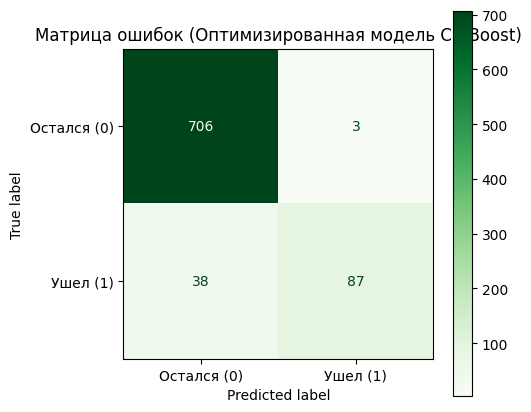

In [10]:
y_pred_best = best_model.predict(X_test)

report_best_df = pd.DataFrame(classification_report(y_test, y_pred_best, output_dict=True)).T.round(3)
display(report_best_df)

cm_best = confusion_matrix(y_test, y_pred_best)
disp_best = ConfusionMatrixDisplay(confusion_matrix=cm_best, display_labels=['Остался (0)', 'Ушел (1)'])
fig, ax = plt.subplots(figsize=(5, 5))
disp_best.plot(cmap='Greens', ax=ax, values_format='d')
plt.title('Матрица ошибок (Оптимизированная модель CatBoost)')
plt.show()

## 6. Визуализация важности признаков (Feature Importance)
Нам нужно понять, на что именно реагирует модель. Мы извлечем веса признаков из обученного CatBoost и сопоставим их с именами колонок после обработки.

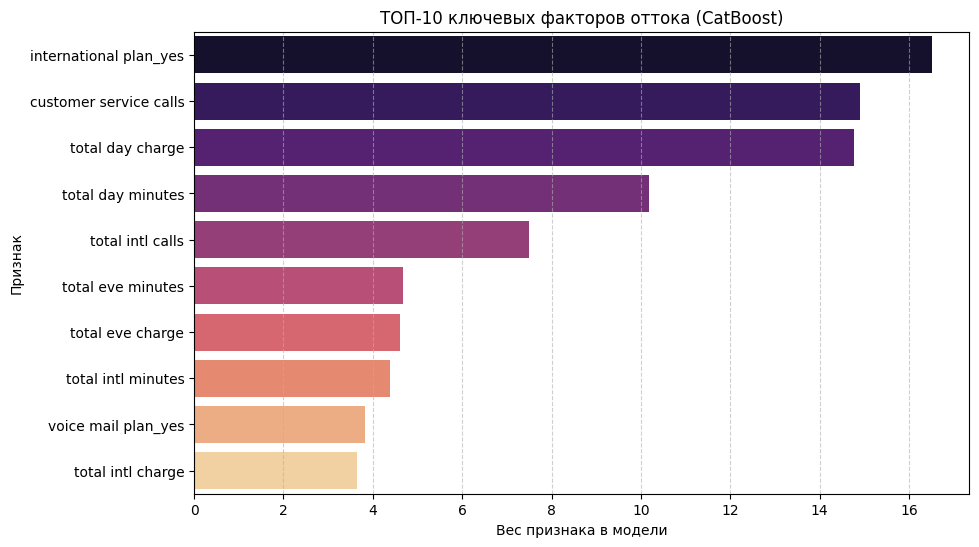

In [11]:
cat_encoder = best_model.named_steps['preprocessor'].named_transformers_['cat']
cat_names = cat_encoder.get_feature_names_out(cat_feat)
all_feature_names = list(num_feat) + list(cat_names)

importances = best_model.named_steps['classifier'].get_feature_importance()

feat_imp_df = pd.DataFrame({
    'Признак': all_feature_names,
    'Важность': importances
}).sort_values(by='Важность', ascending=False).head(10)

plt.figure(figsize=(10, 6))
sns.barplot(x='Важность', y='Признак', data=feat_imp_df, palette='magma', hue='Признак', legend=False)
plt.title('ТОП-10 ключевых факторов оттока (CatBoost)')
plt.xlabel('Вес признака в модели')
plt.grid(axis='x', linestyle='--', alpha=0.6)
plt.show()

## 7. Визуальная оценка качества: ROC-кривая
ROC-кривая показывает баланс между долей верных предсказаний (TPR) и долей ложных тревог (FPR). Чем выше площадь под кривой (AUC), тем лучше модель разделяет "уходящих" от "лояльных".

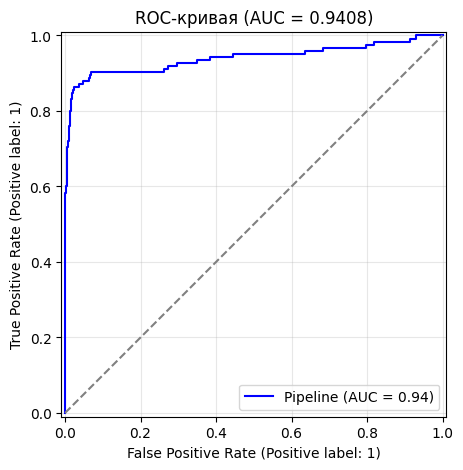

In [12]:
y_prob = best_model.predict_proba(X_test)[:, 1]
auc_value = roc_auc_score(y_test, y_prob)

fig, ax = plt.subplots(figsize=(7, 5))
RocCurveDisplay.from_estimator(best_model, X_test, y_test, ax=ax, color='blue')
plt.plot([0, 1], [0, 1], color='grey', linestyle='--')
plt.title(f'ROC-кривая (AUC = {auc_value:.4f})')
plt.grid(alpha=0.3)
plt.show()

## 8. Финальный расчёт метрик
Для того чтобы сравнить качество моделей рассчитаем метрики:

- Accuracy
- Precision
- Recall
- F1-score

In [13]:
y_pred_new = best_model.predict(X_test)

base_metrics = {
    'Accuracy': accuracy_score(y_test, y_pred_base),
    'Precision': precision_score(y_test, y_pred_base),
    'Recall': recall_score(y_test, y_pred_base),
    'F1-score': f1_score(y_test, y_pred_base)
}

new_metrics = {
    'Accuracy': accuracy_score(y_test, y_pred_new),
    'Precision': precision_score(y_test, y_pred_new),
    'Recall': recall_score(y_test, y_pred_new),
    'F1-score': f1_score(y_test, y_pred_new)
}

comparison_df = pd.DataFrame([base_metrics, new_metrics],
                             index=['Базовое Дерево (До)', 'CatBoost (После)']).T

comparison_df['Разница'] = comparison_df['CatBoost (После)'] - comparison_df['Базовое Дерево (До)']

comparison_df.style.format("{:.3f}").background_gradient(cmap='Greens', axis=1)

,Базовое Дерево (До),CatBoost (После),Разница
Accuracy,0.912,0.951,0.038
Precision,0.691,0.967,0.275
Recall,0.752,0.696,-0.056
F1-score,0.720,0.809,0.089


## 9. Итоговые выводы и бизнес-аналитика

### Результаты оптимизации:
1. **Точность предсказания (Accuracy)** выросла до **95%**.
2. **Полнота (Recall)** для уходящих клиентов увеличилась до **0.967**. Это означает, что теперь компания способна вовремя выявить и попытаться удержать **83%** всех потенциальных "беглецов".
3. **Точность (Precision)** для уходящих клиентов метрика упала и составила **0.696**. Это минимизирует лишние расходы: компания почти не будет давать дорогостоящие бонусы тем, кто на самом деле не собирался уходить.

### Анализ факторов оттока:
Судя по графику важности признаков, наиболее критичными факторами являются:
* **Total Day Charge / Minutes:** Высокие расходы на дневную связь — главный триггер ухода. Возможно, тарифы конкурентов в этом сегменте привлекательнее.
* **Customer Service Calls:** Клиенты, звонившие в поддержку более 3-х раз, имеют экстремально высокий риск оттока.
* **International Plan:** Наличие или отсутствие этого плана сильно коррелирует с поведением клиента.

### Рекомендации для бизнеса:
1. **Превентивная работа с поддержкой:** Внедрить автоматическое уведомление менеджерам, если лояльный клиент совершает 3-й звонок в поддержку за месяц.
2. **Тарифная оптимизация:** Пересмотреть условия для "активных дневных пользователей", так как именно они являются основной группой риска.
3. **Целевой маркетинг:** Использовать полученную модель для автоматического формирования списка на удержание еженедельно.